# Diagram reconstruction

**Reproducibility note:** Results shown were computed on an A100 GPU. Re-running requires a GPU and significant compute time. Pre-computed outputs are preserved here for reference. Result pkl files (~487 MB) are not included in the repository.

## Polynomial diagram fits to anisotropic power-diagram truth

This notebook generates synthetic APDs at several anisotropy levels and fits
them with polynomial minimisation diagrams of order $h_o \in \{1, 2\}$. Each
fit minimises the multinomial logistic-regression surrogate to the hard pixel
assignment by L-BFGS, with a fixed iteration budget `max_iter` as the only
stopping rule. For every configuration we report the truth, the reconstruction,
the per-pixel error map, and the overall pixel-mismatch fraction.

In [1]:
import os

# For the GPU rerun: locate CUDA so KeOps can compile its kernels.
# No effect on a CPU-only laptop run.
if os.path.isdir("/opt/conda/targets/x86_64-linux"):
    os.environ["CUDA_HOME"] = "/opt/conda/targets/x86_64-linux"
    os.environ["PATH"] = f"{os.environ['CUDA_HOME']}/bin:" + os.environ["PATH"]
    os.environ["LD_LIBRARY_PATH"] = (
        f"{os.environ['CUDA_HOME']}/lib:" + os.environ.get("LD_LIBRARY_PATH", "")
    )

In [2]:
import time
import pickle

import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import PyAPD

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

device = "cuda" if torch.cuda.is_available() else "cpu"
dt = torch.float64
torch.set_default_dtype(dt)
torch.set_default_device(device)
torch.set_printoptions(precision=10)

# Flush subnormal floats to zero on x86 CPUs. Harmless on GPU (the hardware
# already flushes denormals), but crucial on the laptop run: the asymptotic
# L-BFGS trajectory of a logistic-regression MLE produces many subnormal
# probabilities which would otherwise be handled by slow microcode.
torch.set_flush_denormal(True)

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

print(f"device = {device},  dtype = {dt}")

device = cuda,  dtype = torch.float64


## Experiment parameters

In [3]:
N        = 50                   # number of grains per diagram
MAX_ITER = 2000                 # L-BFGS iterations — the only stopping rule
EPS      = 1e-2                 # design-matrix scale (a reparametrisation of theta)

PIXEL_SIZE_PREFACTOR        = 2  # initial APD-construction resolution
PIXEL_SIZE_PREFACTOR_REFINE = 2  # (potentially) refined resolution used for the fit

DOMAIN = torch.tensor([[-1.0, 1.0], [-1.0, 1.0]])

## Helpers

`run_apd_to_mds_fit` constructs a synthetic APD truth, fits a polynomial
minimisation diagram to it, and returns a self-contained dictionary of
**CPU tensors and plain-Python metadata**. No live `apd_system` or
`min_diagram_system` objects are kept in the returned dictionary — this is
what makes the pickled results loadable on machines without CUDA.

`grids_and_error` rasterises the truth, the reconstruction, and the per-pixel
error indicator onto the pixel grid, and also builds a deterministic random
colourmap so that truth and reconstruction share consistent grain colours.

In [4]:
def ordinal(n: int) -> str:
    """Return '1st', '2nd', '3rd', '4th', ... for positive integer n."""
    if 10 <= (n % 100) <= 20:
        suf = "th"
    else:
        suf = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suf}"


def run_apd_to_mds_fit(
    N,
    ani_thres,
    seed,
    ho,
    eps=EPS,
    max_iter=MAX_ITER,
    heuristic_guess=False,
    domain=DOMAIN,
    pixel_size_prefactor=PIXEL_SIZE_PREFACTOR,
    pixel_size_prefactor_refine=PIXEL_SIZE_PREFACTOR_REFINE,
    verbose=False,
):
    """Build one APD, fit a polynomial minimisation diagram of order `ho`,
    and return a CPU-only dict with the arrays, metadata, and timings
    needed for plotting and pickling.
    """
    t_total = time.time()

    # --- 1. construct the APD truth -----------------------------------
    t0 = time.time()
    apd = PyAPD.apd_system(
        N=N,
        ani_thres=ani_thres,
        pixel_size_prefactor=pixel_size_prefactor,
        domain=domain,
        seed=seed,
    )
    apd.assemble_pixels()
    apd.Lloyds_algorithm(K=20, verbosity_level=0)
    apd.find_optimal_W()

    if pixel_size_prefactor_refine is not None:
        apd.pixel_size_prefactor = pixel_size_prefactor_refine
        apd.set_pixel_params(verbose=False)
        apd.assemble_pixels()
    I_truth = apd.assemble_apd()
    build_time = time.time() - t0

    # --- 2. fit the minimisation diagram ------------------------------
    mds = PyAPD.min_diagram_system(
        Y=apd.Y,
        grain_map=I_truth,
        pixel_params=apd.pixel_params,
        ho=ho,
        eps=eps,
        heuristic_guess=heuristic_guess,
        dt=dt,
        device=device,
    )
    t0 = time.time()
    mds.fit_theta(
        max_iter=max_iter,
        gtol=0.0,
        xtol=0.0,
        backend="auto",
        verbose=verbose,
    )
    fit_time = time.time() - t0
    I_recon = mds.assemble_diagram()

    total_time = time.time() - t_total

    # --- 3. pack results (CPU only — safe for pickle & laptop reload) --
    return {
        "Y":            mds.Y.detach().cpu().clone(),
        "I_truth":      mds.I.detach().cpu().clone(),
        "I_recon":      I_recon.detach().cpu().clone(),
        "theta":        mds.theta.detach().cpu().clone(),
        "domain":       (domain.detach().cpu().clone()
                         if torch.is_tensor(domain)
                         else torch.as_tensor(domain)),
        "pixel_params": tuple(apd.pixel_params),
        "N":              N,
        "ani_thres":      ani_thres,
        "seed":           seed,
        "ho":             ho,
        "eps":            eps,
        "max_iter":       max_iter,
        "heuristic_guess": heuristic_guess,
        "build_time":   build_time,
        "fit_time":     fit_time,
        "total_time":   total_time,
    }


def grids_and_error(out):
    """Rasterise (truth, reconstruction, error indicator) and return them
    together with the pixel-mismatch fraction and a deterministic colourmap.
    """
    domain  = out["domain"]
    Y       = out["Y"]
    I_truth = out["I_truth"]
    I_recon = out["I_recon"]
    pp      = out["pixel_params"]

    G_truth = PyAPD.gridify_Y_I(Y, I_truth, domain, pp)
    G_recon = PyAPD.gridify_Y_I(Y, I_recon, domain, pp)
    err_vec = (I_truth != I_recon).to(torch.float32)
    G_err   = PyAPD.gridify_Y_I(Y, err_vec, domain, pp)
    pe      = err_vec.mean().item()  # fraction in [0, 1]

    n_lbl = int(I_truth.max().item()) + 1
    rng   = np.random.default_rng(0)  # deterministic grain colours
    cmap_lbl = ListedColormap(rng.uniform(0.1, 0.95, size=(n_lbl, 3)))

    return G_truth, G_recon, G_err, pe, cmap_lbl, n_lbl

## Experimental configurations

Five base configurations sweep the anisotropy threshold and the fit order
$h_o$:

| tag | truth              | `ani_thres` | seed | $h_o$ |
|:---:|:-------------------|:-----------:|:----:|:-----:|
|  A  | power diagram      | 0.00        | 10   | 1     |
|  B  | anisotropic PD     | 0.35        | 11   | 1     |
|  C  | anisotropic PD     | 0.35        | 11   | 2     |
|  D  | anisotropic PD     | 0.75        | 13   | 1     |
|  E  | anisotropic PD     | 0.75        | 13   | 2     |

Each base configuration is run twice: once from a cold start and once from the
physical heuristic guess of `physical_heuristic_guess`. Warm-started runs carry
a doubled tag (`AA`, `BB`, ...) for filename disambiguation.

The fit objective is convex in $\theta$ under the linear parametrisation, so
the cold-start and heuristic-start runs differ only in the L-BFGS trajectory,
not in the limiting minimiser. Both are recorded for completeness.

In [5]:
spec = [
    dict(tag="A", truth_title="Truth (PD)",  ani_thres=0.00, seed=10, ho=1),
    dict(tag="B", truth_title="Truth (APD)", ani_thres=0.35, seed=11, ho=1),
    dict(tag="C", truth_title="Truth (APD)", ani_thres=0.35, seed=11, ho=2),
    dict(tag="D", truth_title="Truth (APD)", ani_thres=0.75, seed=13, ho=1),
    dict(tag="E", truth_title="Truth (APD)", ani_thres=0.75, seed=13, ho=2),
]

configs = (
    [{**s, "heuristic_guess": False} for s in spec]
    + [{**s, "tag": s["tag"] * 2, "heuristic_guess": True} for s in spec]
)

print(f"{len(configs)} configurations: {[c['tag'] for c in configs]}")

10 configurations: ['A', 'B', 'C', 'D', 'E', 'AA', 'BB', 'CC', 'DD', 'EE']


## Run the sweep

Each configuration constructs its own APD truth, fits `MAX_ITER` L-BFGS
iterations, and packs a CPU-only result dictionary.

In [6]:
outs = []
for cfg in configs:
    print(f"[{cfg['tag']}] ani={cfg['ani_thres']:.2f}  seed={cfg['seed']}  "
          f"ho={cfg['ho']}  heuristic={cfg['heuristic_guess']}")
    out = run_apd_to_mds_fit(
        N=N,
        ani_thres=cfg["ani_thres"],
        seed=cfg["seed"],
        ho=cfg["ho"],
        heuristic_guess=cfg["heuristic_guess"],
    )
    outs.append(out)
    print(f"         build={out['build_time']:5.2f}s  "
          f"fit={out['fit_time']:6.2f}s  "
          f"total={out['total_time']:6.2f}s")

[A] ani=0.00  seed=10  ho=1  heuristic=False
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.5102343559265137
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.7653143405914307
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.7653236389160156
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.7653050422668457
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.7653329372406006
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.7653236389160156
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.510280966758728
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.7653050422668457
Optimality condition successfully overwritten.
The APD is optimal!
Percentage error =  0.7653050422668457
Op

## Visualisation

For each configuration we produce a single $1 \times 3$ figure showing the
APD truth, the polynomial minimisation-diagram reconstruction, and the
per-pixel error indicator, with the reconstruction error annotated in the
error-panel title. Figures are saved as `figures/recon_{j}.pdf`.

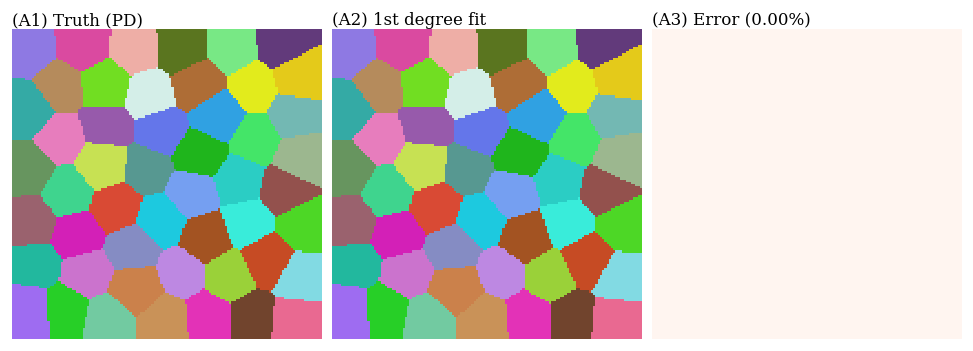

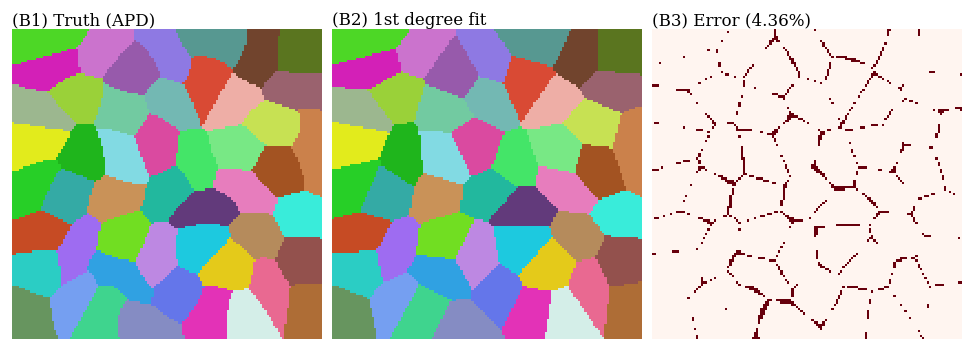

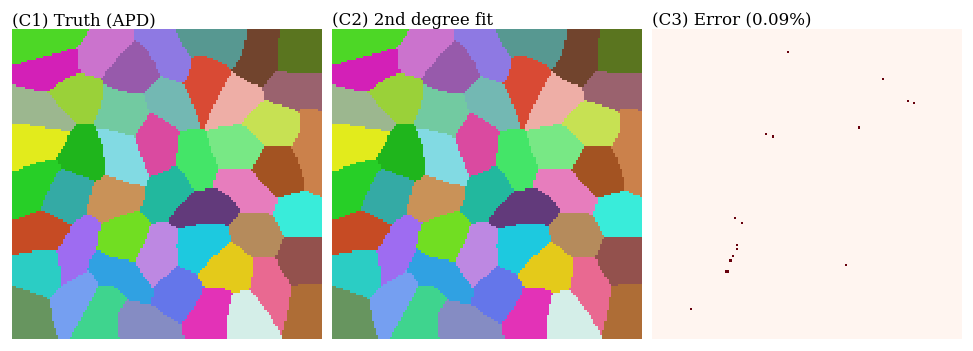

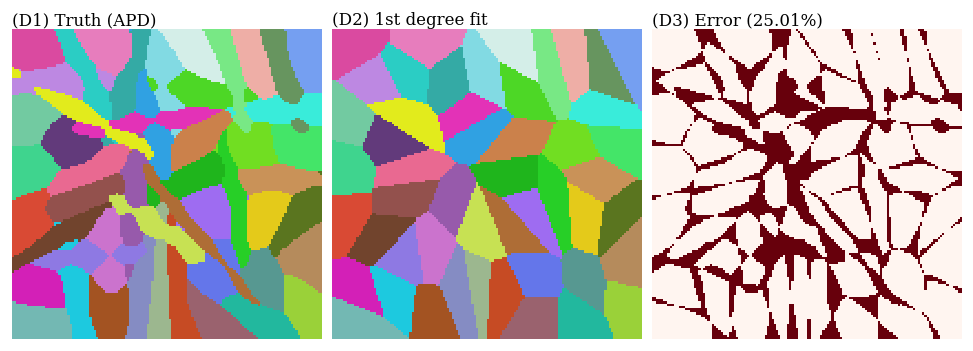

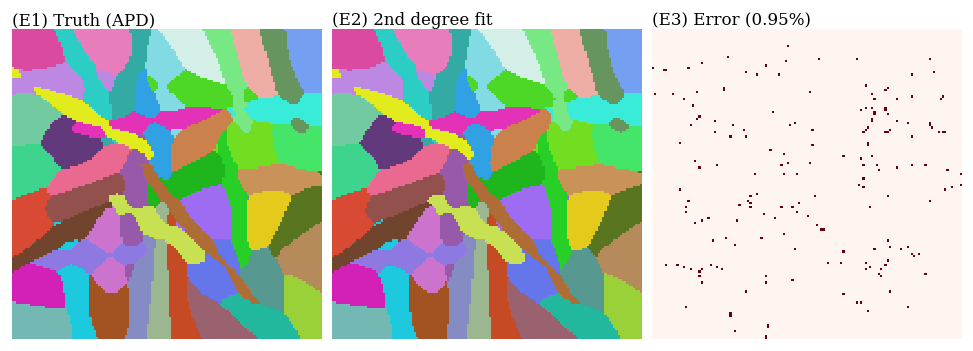

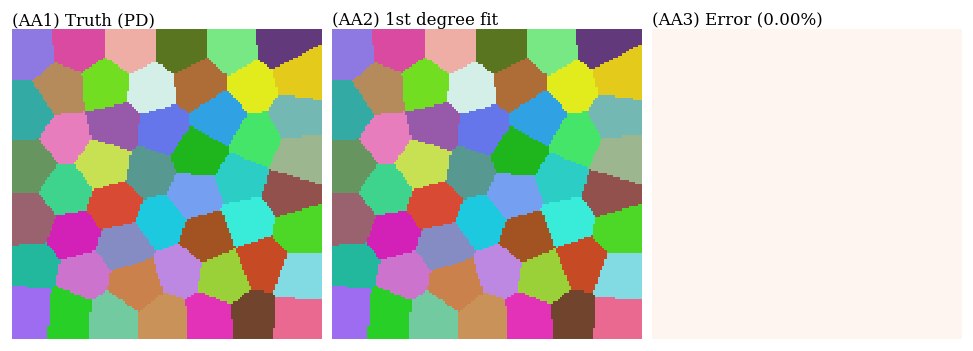

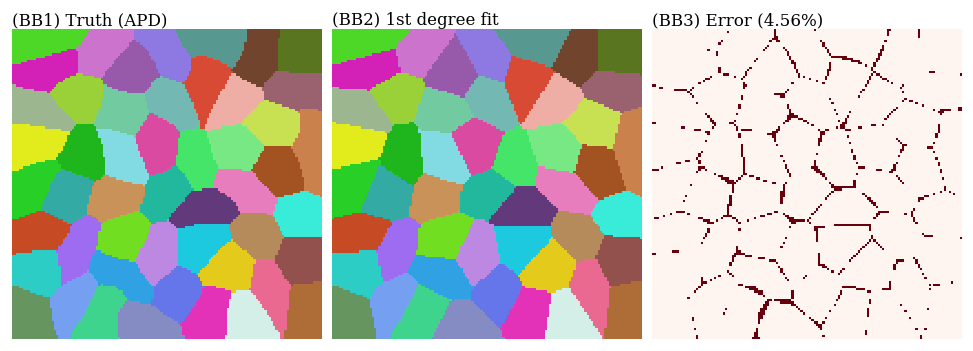

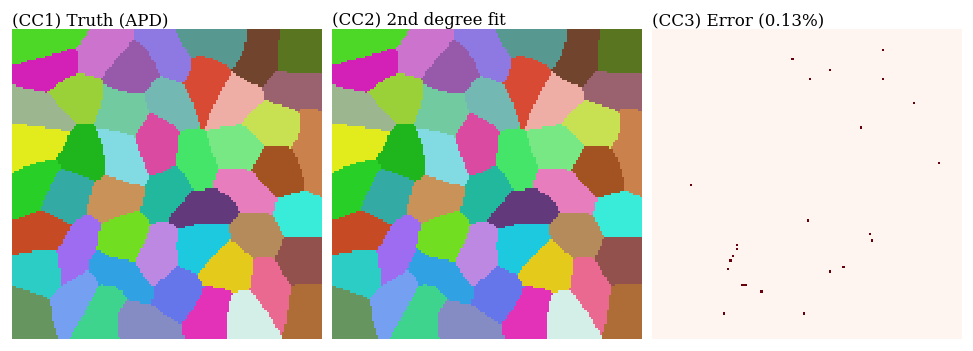

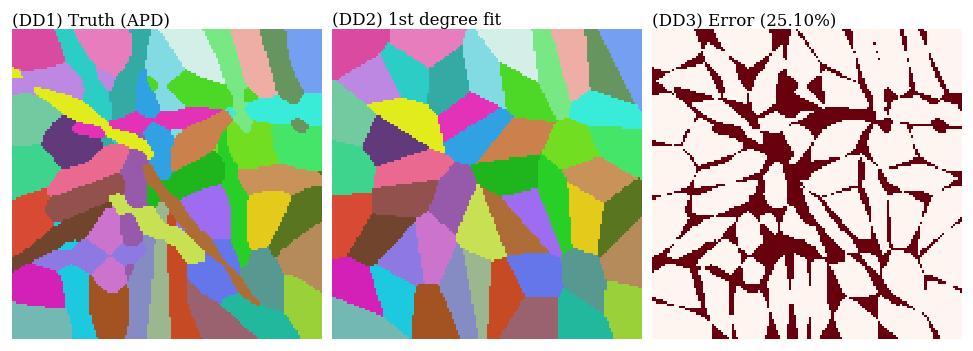

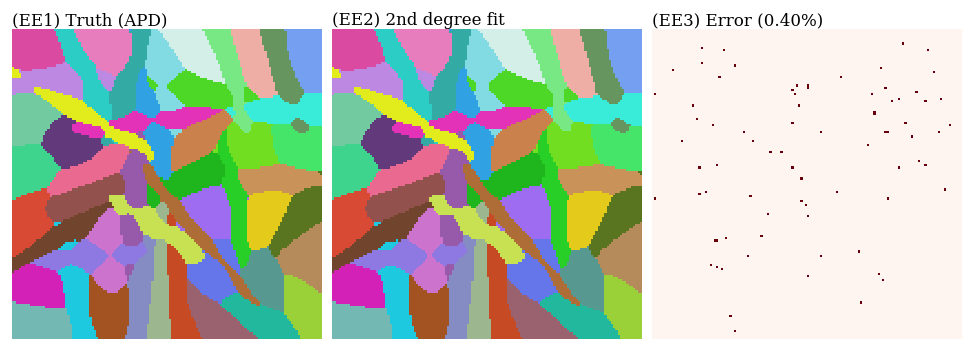

In [7]:
for j, (cfg, out) in enumerate(zip(configs, outs)):
    G_truth, G_recon, G_err, pe, cmap_lbl, n_lbl = grids_and_error(out)
    deg = out["ho"]
    tag = cfg["tag"]

    fig, ax = plt.subplots(1, 3, figsize=(8.0, 3.6), constrained_layout=True)

    ax[0].imshow(G_truth, origin="lower", interpolation="nearest",
                 cmap=cmap_lbl, vmin=0, vmax=n_lbl - 1)
    ax[0].set_title(f"({tag}1) {cfg['truth_title']}", loc="left", pad=3)

    ax[1].imshow(G_recon, origin="lower", interpolation="nearest",
                 cmap=cmap_lbl, vmin=0, vmax=n_lbl - 1)
    ax[1].set_title(f"({tag}2) {ordinal(deg)} degree fit", loc="left", pad=3)

    ax[2].imshow(G_err, origin="lower", interpolation="nearest",
                 cmap="Reds", vmin=0, vmax=1)
    ax[2].set_title(f"({tag}3) Error ({100 * pe:.2f}%)", loc="left", pad=3)

    for a in ax:
        a.set_aspect("equal")
        a.set_axis_off()

    fig.savefig(f"figures/recon_{j}.pdf", bbox_inches="tight", pad_inches=0.01)
    plt.show()

## Summary table

In [8]:
print(
    f"{'tag':<4}  {'N':>4}  {'pixels':>8}  {'ani':>5}  {'ho':>3}  "
    f"{'seed':>5}  {'heur':>5}  {'max_iter':>8}  {'build(s)':>8}  "
    f"{'fit(s)':>8}  {'total(s)':>8}  {'pixel err':>9}"
)
print("-" * 97)
for cfg, out in zip(configs, outs):
    _, _, _, pe, _, _ = grids_and_error(out)
    M = out["Y"].shape[0]
    print(
        f"{cfg['tag']:<4}  "
        f"{out['N']:>4}  "
        f"{M:>8}  "
        f"{cfg['ani_thres']:>5.2f}  "
        f"{cfg['ho']:>3}  "
        f"{cfg['seed']:>5}  "
        f"{str(cfg['heuristic_guess']):>5}  "
        f"{out['max_iter']:>8}  "
        f"{out['build_time']:>8.2f}  "
        f"{out['fit_time']:>8.2f}  "
        f"{out['total_time']:>8.2f}  "
        f"{100 * pe:>8.3f}%"
    )

tag      N    pixels    ani   ho   seed   heur  max_iter  build(s)    fit(s)  total(s)  pixel err
-------------------------------------------------------------------------------------------------
A       50     19600   0.00    1     10  False      2000      0.78     10.52     11.30     0.000%
B       50     19600   0.35    1     11  False      2000      0.35     32.13     32.48     4.362%
C       50     19600   0.35    2     11  False      2000      0.36     33.47     33.89     0.087%
D       50     19600   0.75    1     13  False      2000      0.41     40.77     41.19    25.005%
E       50     19600   0.75    2     13  False      2000      0.43     32.95     33.38     0.954%
AA      50     19600   0.00    1     10   True      2000      0.36     11.76     12.13     0.000%
BB      50     19600   0.35    1     11   True      2000      0.34     31.54     31.89     4.561%
CC      50     19600   0.35    2     11   True      2000      0.35     33.10     33.92     0.128%
DD      50     19600

## Saving the data to reproduce the figures

Results are pickled as two files:

- `results/recon_configs.pkl` — the list of configuration dictionaries.
- `results/recon_outs.pkl` — the list of CPU-only result dictionaries.

Every tensor in `outs` already lives on CPU (see `run_apd_to_mds_fit`), so the
pickle can be loaded on any machine without a CUDA runtime — figures can be
regenerated from the saved arrays alone.

In [9]:
with open("results/recon_configs.pkl", "wb") as f:
    pickle.dump(configs, f, protocol=pickle.HIGHEST_PROTOCOL)

with open("results/recon_outs.pkl", "wb") as f:
    pickle.dump(outs, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Wrote results/recon_configs.pkl and results/recon_outs.pkl")

Wrote results/recon_configs.pkl and results/recon_outs.pkl


## Reload and re-plot from pickle

A sanity check that the pickled `results/recon_outs.pkl` is fully self-contained:
we load it back into fresh variables, regenerate the same $1 \times 3$ figures
from the CPU-only arrays, and display them *without* writing any PDFs. This is
the workflow used when regenerating paper figures on a laptop from pickles
produced on a GPU box.

Reloaded 10 configurations and 10 results.


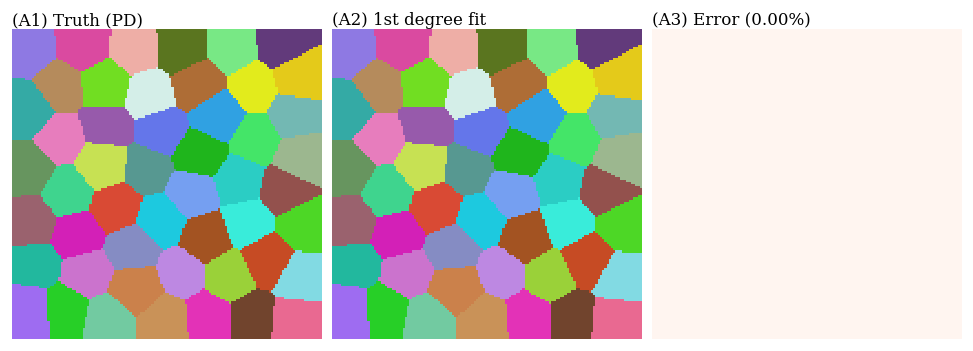

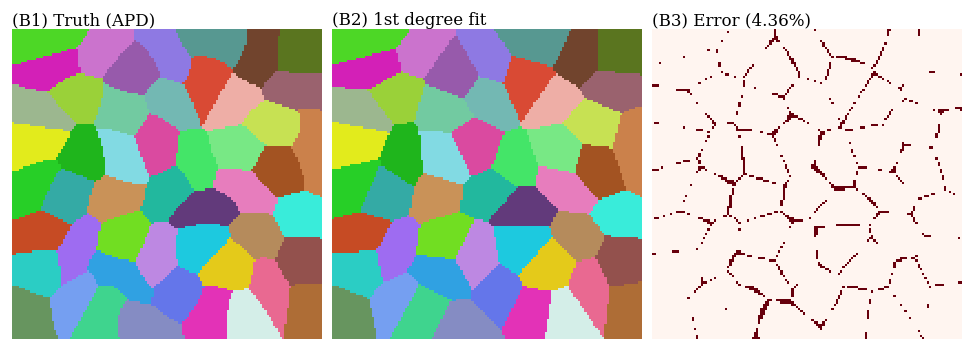

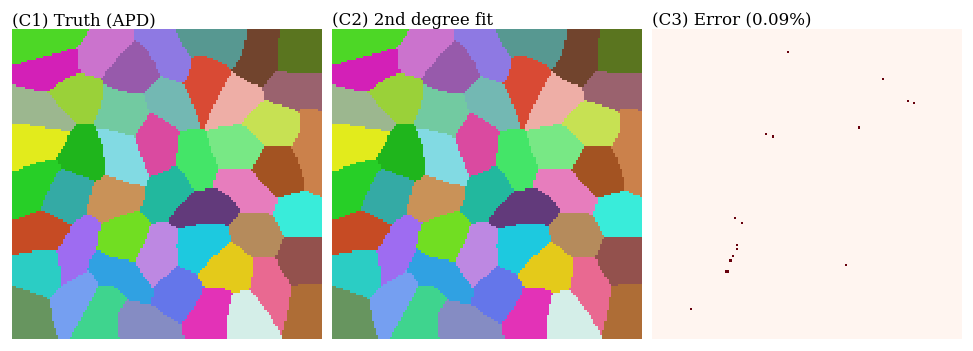

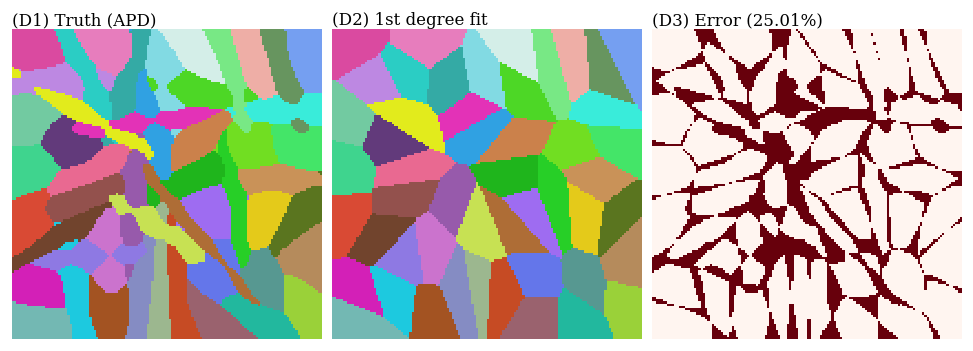

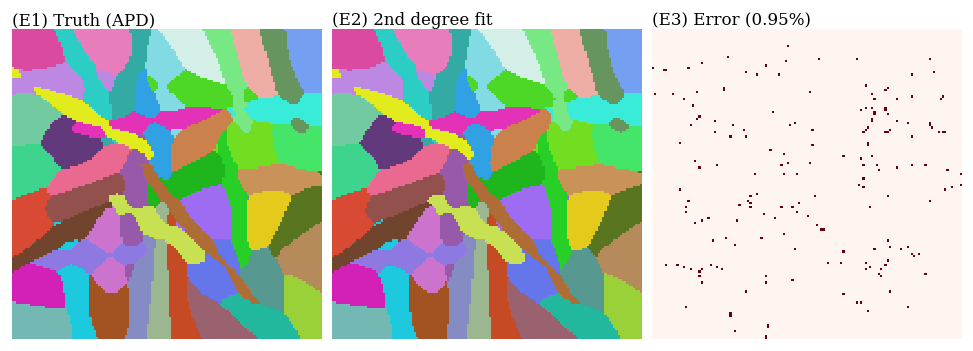

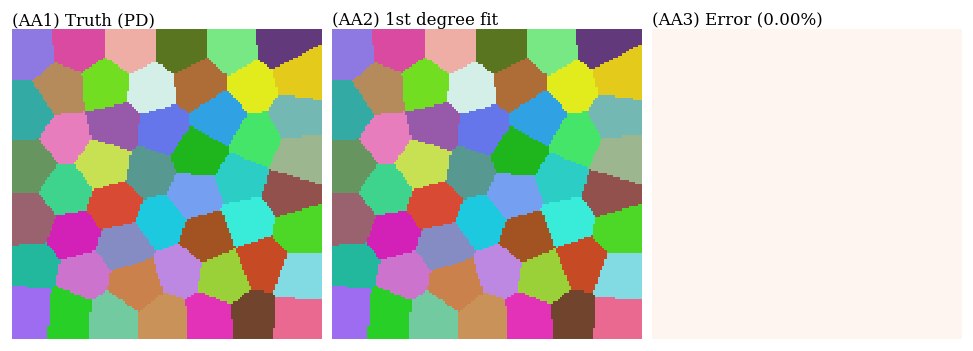

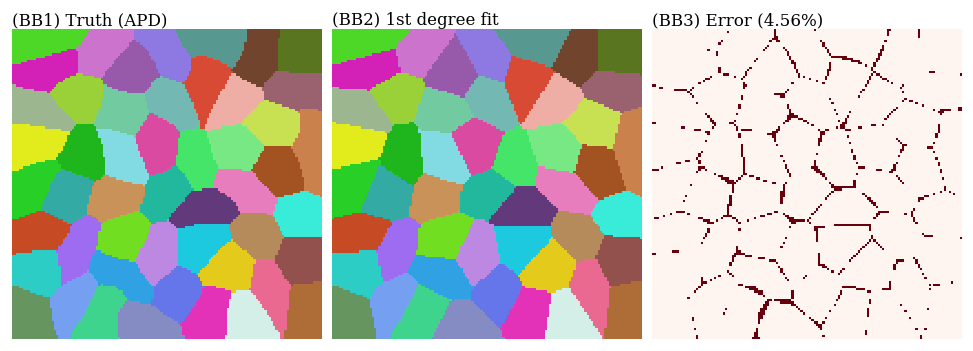

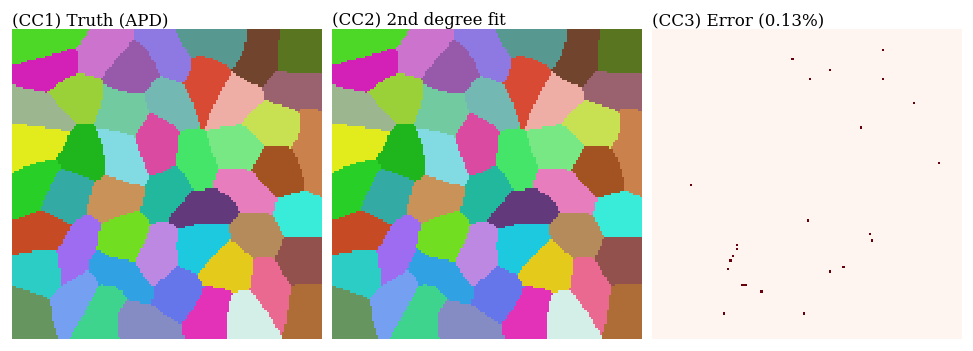

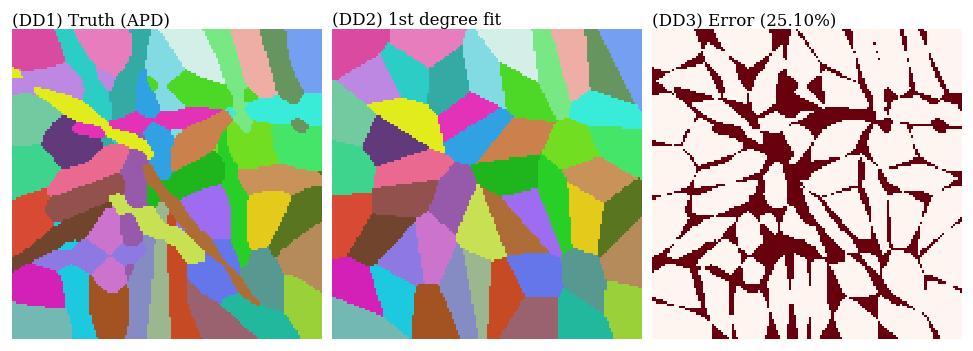

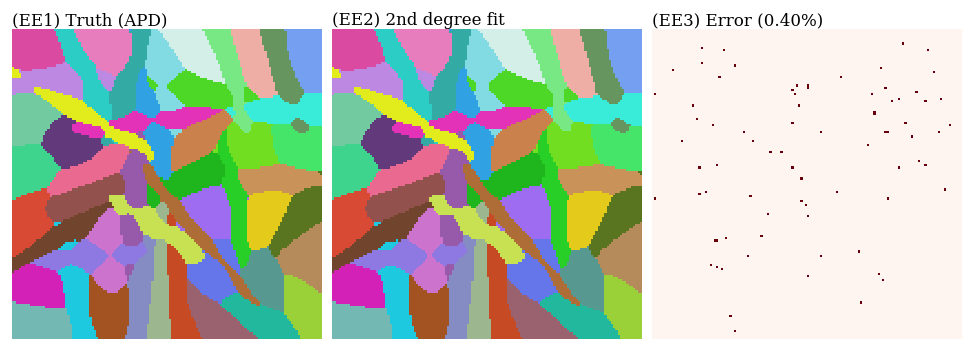

In [10]:
with open("results/recon_configs.pkl", "rb") as f:
    configs_loaded = pickle.load(f)

with open("results/recon_outs.pkl", "rb") as f:
    outs_loaded = pickle.load(f)

print(f"Reloaded {len(configs_loaded)} configurations and {len(outs_loaded)} results.")

for j, (cfg, out) in enumerate(zip(configs_loaded, outs_loaded)):
    G_truth, G_recon, G_err, pe, cmap_lbl, n_lbl = grids_and_error(out)
    deg = out["ho"]
    tag = cfg["tag"]

    fig, ax = plt.subplots(1, 3, figsize=(8.0, 3.6), constrained_layout=True)

    ax[0].imshow(G_truth, origin="lower", interpolation="nearest",
                 cmap=cmap_lbl, vmin=0, vmax=n_lbl - 1)
    ax[0].set_title(f"({tag}1) {cfg['truth_title']}", loc="left", pad=3)

    ax[1].imshow(G_recon, origin="lower", interpolation="nearest",
                 cmap=cmap_lbl, vmin=0, vmax=n_lbl - 1)
    ax[1].set_title(f"({tag}2) {ordinal(deg)} degree fit", loc="left", pad=3)

    ax[2].imshow(G_err, origin="lower", interpolation="nearest",
                 cmap="Reds", vmin=0, vmax=1)
    ax[2].set_title(f"({tag}3) Error ({100 * pe:.2f}%)", loc="left", pad=3)

    for a in ax:
        a.set_aspect("equal")
        a.set_axis_off()

    plt.show()